In [1]:
import os
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from dotenv import load_dotenv
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

# Notebook/ -> 04_Python/ -> raiz do projeto
RAIZ = Path.cwd().parents[1]
SAIDA_IMG = RAIZ / "05_PowerBI" / "Imagens"
SAIDA_CSV = RAIZ / "05_PowerBI" / "Tabelas"
SAIDA_IMG.mkdir(parents=True, exist_ok=True)
SAIDA_CSV.mkdir(parents=True, exist_ok=True)

load_dotenv(RAIZ / ".env")
engine = create_engine(URL.create(
    "postgresql+psycopg2",
    username=os.getenv("PGUSER"), password=os.getenv("PGPASSWORD"),
    host=os.getenv("PGHOST"), port=int(os.getenv("PGPORT")),
    database=os.getenv("PGDATABASE"),
))

# As duas últimas colunas são calculadas na consulta, não guardadas no banco:
# ST_Transform lê a geometria e devolve graus decimais. A coluna `geom`
# continua em SRID 31983 (UTM 23S), que é a projeção do projeto — 4326 serve
# só para o visual de mapa do Power BI, que não entende sistema projetado.
COLUNAS = ("id_ponto, id_trilha, tipo, declividade, solo, condicoes_trilha, "
           "sinais_erosao, obstaculos_riscos, nivel_perigo, escala_perigo, "
           "ST_X(ST_Transform(geom, 4326)) AS longitude, "
           "ST_Y(ST_Transform(geom, 4326)) AS latitude")

pontos = pd.read_sql(
    " UNION ALL ".join(
        f"SELECT {COLUNAS} FROM public.pontos_trilha_{i}" for i in (1, 2, 3)),
    engine)

fotos = pd.read_sql(
    " UNION ALL ".join(
        f"SELECT id_foto, id_ponto, arquivo, caminho "
        f"FROM public.fotos_trilha_{i}_stg"
        for i in (1, 2, 3)),
    engine)

# O Power BI só exibe imagem a partir de URL pública — caminho local não
# funciona depois de publicado. As 144 fotos já estão versionadas no
# repositório, então a URL é o prefixo do raw + o caminho relativo.
REPO = "https://raw.githubusercontent.com/carinebrum/projeto-pedra-branca/main/"
fotos["url"] = REPO + fotos["caminho"]

NOMES_TRILHA = {"T01": "Pau da Fome", "T02": "Pedra Negra",
                "T03": "Morro dos Caboclos"}
pontos["trilha"] = pontos["id_trilha"].map(NOMES_TRILHA)

print(f"Pontos: {len(pontos)}   Fotos: {len(fotos)}")
pontos.head()


Pontos: 70   Fotos: 144


,id_ponto,id_trilha,tipo,declividade,solo,condicoes_trilha,sinais_erosao,obstaculos_riscos,nivel_perigo,escala_perigo,longitude,latitude,trilha
0,T1P001,T01,Drenagem,Muito Baixa,Misto (Arenoso/argiloso),Largura pouco mens de 1 metro com degraus natu...,Desgaste do solo por fluxo de pessoas e de água,,Baixo,2,-43.443344,-22.932505,Pau da Fome
1,T1P002,T01,Erosão,Muito Baixa,Arenoso,"Largura de cerca de 1 metro, observa-se um des...",Deslizamento do lado direito da trilha,Troncos caidos,Médio,3,-43.444344,-22.933536,Pau da Fome
2,T1P003,T01,Drenagem,Baixa,Arenoso,Largura de aproximadamente 8 metros e presença...,Solo apresenta muito desnível devido a erosão ...,Risco de queda,Baixo,2,-43.444955,-22.933708,Pau da Fome
3,T1P004,T01,Declive,Muito Baixa,Arenoso,1.20 metros de largura com uma área de declive...,Solo pouco compactado e escorregadio do lado d...,Risco de queda,Baixo,2,-43.445456,-22.933884,Pau da Fome
4,T1P005,T01,Drenagem,Baixa,Arenoso,Rio com cerca de 10 metros de uma margem até a...,,Rio,Alto,4,-43.446826,-22.934013,Pau da Fome


In [2]:
for coluna in ["id_trilha", "tipo", "declividade", "solo",
               "nivel_perigo", "escala_perigo"]:
    contagem = pontos[coluna].value_counts(dropna=False)
    print(f"\n### {coluna} — {len(contagem)} valores distintos")
    for valor, n in contagem.items():
        print(f"   {n:>3}  {valor!r}")

for coluna in ["sinais_erosao", "obstaculos_riscos", "condicoes_trilha"]:
    serie = pontos[coluna].dropna()
    print(f"\n### {coluna} — {serie.nunique()} distintos em {len(serie)} "
          f"preenchidos, {serie.str.len().mean():.0f} caracteres em média")
    for texto in serie.head(3):
        print(f"   - {texto[:100]}")



### id_trilha — 3 valores distintos
    35  'T01'
    20  'T03'
    15  'T02'

### tipo — 8 valores distintos
    24  'Declive'
    16  'Erosão'
    10  'Passagem'
     8  'Drenagem'
     7  'Obstaculo'
     2  'Deslizamento'
     2  'Mata Fechada'
     1  'Pico Pedra Branca'

### declividade — 5 valores distintos
    29  'Baixa'
    18  'Média'
    14  'Alta'
     5  'Muito Alta'
     4  'Muito Baixa'

### solo — 7 valores distintos
    39  'Arenoso'
    17  'Misto (Arenoso/argiloso)'
     6  'Argiloso'
     4  'Argiloso saturado'
     2  'Arenoso (areia fina)'
     1  'Arenoso mal selecionado'
     1  'Arenoso pouco compacto'

### nivel_perigo — 5 valores distintos
    22  'Médio'
    20  'Baixo'
    13  'Alto'
    10  'Muito Alto'
     5  'Muito Baixo'

### escala_perigo — 5 valores distintos
    22  3
    20  2
    13  4
    10  5
     5  1

### sinais_erosao — 23 distintos em 70 preenchidos, 19 caracteres em média
   - Desgaste do solo por fluxo de pessoas e de água
   - Deslizam

In [3]:
for coluna in ["sinais_erosao", "obstaculos_riscos"]:
    serie = pontos[coluna].fillna("").str.strip()
    vazios = (serie == "").sum()
    print(f"\n{'='*70}\n### {coluna} — {serie.nunique()} distintos "
          f"({vazios} vazios)\n{'='*70}")
    for valor, n in serie.value_counts().items():
        print(f"   {n:>3}  {valor if valor else '(vazio)'}")



### sinais_erosao — 22 distintos (33 vazios)
    33  (vazio)
     8  Erosão em sulco
     5  Erosão laminar
     3  Erosão Laminar
     2  Erosão laminar e em sulco
     2  Erosão laminar evoluindo para sulco
     2  Erosão em sulco formando uma trilha alternativa
     1  Desgaste do solo por fluxo de pessoas e de água
     1  Deslizamento do lado direito da trilha
     1  Solo apresenta muito desnível devido a erosão laminar presente
     1  Solo pouco compactado e escorregadio do lado direito da  trilha
     1  Margem do rio sofre erosão, principalmente laminar
     1  Solo não compactado na borda da trilha
     1  Foi formado um caminho alternativo do lado direito da trilha devido a erosão em estágios mais avançados
     1  Rochas e raízes expostas no solo
     1  Solo removido devido ao fluxo de água
     1  Blocos expostos no solo erodido pela água
     1  Erosão laminar com erosão em sulco em estágio inicial
     1  Piso muito irregular evidenciando processos erosivos neste trec

In [4]:
# =====================================================================
# CÉLULA 3 — Preparo das categorias
# =====================================================================

# --- 1. Declividade e perigo: ordens confirmadas pela Célula 2 --------
ORDEM_DECLIVIDADE = ["Muito Baixa", "Baixa", "Média", "Alta", "Muito Alta"]
ROTULO_PERIGO = {1: "1 Muito Baixo", 2: "2 Baixo", 3: "3 Médio",
                 4: "4 Alto", 5: "5 Muito Alto"}

fora = set(pontos["declividade"].dropna()) - set(ORDEM_DECLIVIDADE)
if fora:
    print("ATENÇÃO — declividade fora da ordem definida:", fora)

pontos["declividade"] = pd.Categorical(
    pontos["declividade"], categories=ORDEM_DECLIVIDADE, ordered=True)
pontos["perigo"] = pd.Categorical(
    pontos["escala_perigo"].map(ROTULO_PERIGO),
    categories=list(ROTULO_PERIGO.values()), ordered=True)
pontos["critico"] = pontos["escala_perigo"] >= 4

# --- 2. Limpeza dos campos de texto ----------------------------------
# Os vazios estão gravados como '' e não como NULL, e há espaços nas pontas.
for coluna in ["sinais_erosao", "obstaculos_riscos", "condicoes_trilha"]:
    pontos[coluna] = pontos[coluna].fillna("").str.strip()

# --- 3. Família de solo ----------------------------------------------
# São 7 valores, quatro deles com 1 ou 2 pontos — sem agrupar, o mapa de
# calor fica com linhas quase vazias. A coluna `solo` original é preservada.
# "Misto" é testado primeiro porque o texto contém "Arenoso" dentro dele.
def familia_solo(valor):
    v = (valor or "").lower()
    if "misto" in v:
        return "Misto"
    if "argiloso" in v:
        return "Argiloso"
    if "arenoso" in v:
        return "Arenoso"
    return "Não informado"

ORDEM_SOLO = ["Arenoso", "Misto", "Argiloso", "Não informado"]
pontos["familia_solo"] = pd.Categorical(
    pontos["solo"].apply(familia_solo), categories=ORDEM_SOLO, ordered=True)

# --- 4. Classe de processo erosivo -----------------------------------
# Construída sobre os 22 valores distintos observados na Célula 2b.
# A ORDEM importa: o primeiro padrão que casar vence, então as combinações
# vêm antes dos tipos puros.
#   s[iu]lco        -> cobre o erro de digitação "silco"
#   (?=.*a)(?=.*b)  -> exige que os dois termos apareçam no mesmo texto
# Rótulo do ponto sem preenchimento. Fica numa constante porque é
# comparado em quatro células diferentes — trocar o texto solto já
# quebrou a contagem uma vez.
SEM_REGISTRO = "Sem sinal erosivo registrado"

REGRAS_EROSAO = [
    ("Laminar e sulco",              r"(?=.*laminar)(?=.*s[iu]lco)"),
    ("Sulco",                        r"s[iu]lco"),
    ("Laminar",                      r"laminar"),
    ("Deslizamento",                 r"deslizamento"),
    ("Exposição de rochas e raízes", r"(rocha|ra[íi]z|bloco).*exposto?a?s?"),
    ("Remoção pelo fluxo de água",   r"desgaste|removido"),
    ("Solo não compactado",          r"(n[ãa]o|pouco)\s+compactad"),
    ("Processo não especificado",    r"erosiv|estágios mais avançados"),
]

def classificar_erosao(texto):
    # Campo em branco significa que a coluna `sinais_erosao` da caderneta
    # não foi preenchida — NÃO que o ponto esteja livre de erosão. Em 22
    # dos 33 pontos em branco a evidência do processo foi anotada na outra
    # coluna, `obstaculos_riscos`: piso escorregadio, borda de declive
    # instável, árvore derrubada. Por isso o rótulo fala em ausência de
    # registro, e não em ausência do processo erosivo.
    if not texto:
        return SEM_REGISTRO
    for rotulo, padrao in REGRAS_EROSAO:
        if re.search(padrao, texto, re.IGNORECASE):
            return rotulo
    return "Outros"

# Ordem de severidade crescente, para o gráfico sair legível
ORDEM_EROSAO = [SEM_REGISTRO, "Solo não compactado",
                "Exposição de rochas e raízes", "Remoção pelo fluxo de água",
                "Processo não especificado", "Laminar", "Laminar e sulco",
                "Sulco", "Deslizamento", "Outros"]

pontos["classe_erosao"] = pd.Categorical(
    pontos["sinais_erosao"].apply(classificar_erosao),
    categories=ORDEM_EROSAO, ordered=True)

# --- 5. Auditoria da classificação -----------------------------------
print("=== Família de solo ===")
print(pontos["familia_solo"].value_counts()[lambda s: s > 0].to_string(), "\n")

print("=== Classe de erosão ===")
print(pontos["classe_erosao"].value_counts()[lambda s: s > 0].to_string(), "\n")

print("=== Conferência: como cada texto foi enquadrado ===")
conferencia = (pontos[pontos.sinais_erosao != ""]
               .groupby(["classe_erosao", "sinais_erosao"], observed=True)
               .size().sort_index())
for (classe, texto), n in conferencia.items():
    print(f"  {classe:<30} {n:>2}x  {texto[:65]}")

nao_classificados = (pontos.classe_erosao == "Outros").sum()
print(f"\nNão classificados ('Outros'): {nao_classificados}")


=== Família de solo ===
familia_solo
Arenoso     43
Misto       17
Argiloso    10 

=== Classe de erosão ===
classe_erosao
Sem sinal erosivo registrado    33
Sulco                           12
Laminar                         10
Laminar e sulco                  6
Solo não compactado              2
Exposição de rochas e raízes     2
Remoção pelo fluxo de água       2
Processo não especificado        2
Deslizamento                     1 

=== Conferência: como cada texto foi enquadrado ===
  Solo não compactado             1x  Solo não compactado na borda da trilha
  Solo não compactado             1x  Solo pouco compactado e escorregadio do lado direito da  trilha
  Exposição de rochas e raízes    1x  Blocos expostos no solo erodido pela água
  Exposição de rochas e raízes    1x  Rochas e raízes expostas no solo
  Remoção pelo fluxo de água      1x  Desgaste do solo por fluxo de pessoas e de água
  Remoção pelo fluxo de água      1x  Solo removido devido ao fluxo de água
  Processo não e

In [5]:
# Conferência rápida dos marcadores de evidência antes da Célula 9b.
EVIDENCIAS = {
    "risco_queda":          r"risco de queda|alto risco de queda",
    "risco_escorregamento": r"ri+sco de escorregamento|escorregadio",
    "tronco_galho":         r"tronco|galho|cip[óo]",
    "area_declive":         r"declive|declividade|deslizamento",
    "curso_dagua":          r"\brio\b",
}
for nome, padrao in EVIDENCIAS.items():
    pontos[nome] = pontos["obstaculos_riscos"].str.contains(
        padrao, case=False, regex=True)

print(pontos[list(EVIDENCIAS)].sum().sort_values(ascending=False).to_string())


risco_escorregamento    21
area_declive            17
risco_queda             13
tronco_galho            11
curso_dagua              2


In [6]:
# =====================================================================
# CÉLULA 4 — Paleta e estilo
# =====================================================================
SUPERFICIE  = "#fcfcfd"
TINTA       = "#14141c"
TINTA_FRACA = "#5a5f70"          # cinza azulado
GRADE       = "#e4e5ec"
VAZIO       = "#f1f2f6"          # célula sem ocorrência nos mapas de calor

# Ordinal — a escala de perigo do projeto, a mesma dos mapas do QGIS:
# azul, verde, amarelo, laranja, vermelho, do nível 1 ao 5.
ESCALA_PERIGO = ["#2a78d6", "#1a9641", "#f2c500", "#eb6834", "#c1272d"]
# Tinta do rótulo sobre cada faixa: branco só onde o fundo é escuro
ROTULO_PERIGO_TINTA = ["#ffffff", TINTA, TINTA, TINTA, "#ffffff"]

# Ordinal — intensidade nos mapas de calor, um só matiz do claro ao escuro.
# Roxo, e não azul: azul já significa "perigo 1" e não pode significar
# "contagem baixa" no mesmo painel.
RAMPA_ROXO  = ["#af9aff", "#9781e4", "#7f68ca", "#6850af", "#533995"]

SERIE_UNICA = "#d55181"          # magenta — barras de uma série só
DESTAQUE    = "#4a3aa7"          # roxo — números em destaque

# A trilha não recebe cor: ela é sempre eixo ou filtro, nunca canal de cor.
# Com azul, verde, amarelo, laranja e vermelho já ocupados pela escala de
# perigo, colorir a trilha só criaria ambiguidade.

plt.rcParams.update({
    "figure.facecolor": SUPERFICIE, "axes.facecolor": SUPERFICIE,
    "font.family": "DejaVu Sans", "font.size": 10,
    "text.color": TINTA, "axes.labelcolor": TINTA_FRACA,
    "xtick.color": TINTA_FRACA, "ytick.color": TINTA_FRACA,
    "axes.titlesize": 13, "axes.titleweight": "bold",
    "axes.titlecolor": TINTA, "axes.titlepad": 14,
    "figure.dpi": 110,
})

def limpar(ax, eixo_valor="x"):
    """Remove molduras e deixa a grade recessiva, só no eixo do valor."""
    for lado in ("top", "right", "left" if eixo_valor == "x" else "bottom"):
        ax.spines[lado].set_visible(False)
    ax.spines["bottom" if eixo_valor == "x" else "left"].set_color(GRADE)
    ax.grid(axis=eixo_valor, color=GRADE, linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    ax.tick_params(length=0)
    return ax

def salvar(fig, nome):
    caminho = SAIDA_IMG / nome
    fig.savefig(caminho, dpi=200, bbox_inches="tight", facecolor=SUPERFICIE)
    print("salvo:", caminho.name)


In [7]:
# =====================================================================
# CÉLULA 5 — Síntese por trilha
# =====================================================================
fotos_por_trilha = (fotos.assign(id_trilha="T0" + fotos.id_ponto.str[1])
                         .groupby("id_trilha").size())

sintese = pontos.groupby("id_trilha").agg(
    trilha=("trilha", "first"),
    pontos=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    pontos_criticos=("critico", "sum"),
).join(fotos_por_trilha.rename("fotos"))

sintese["pct_criticos"] = (100 * sintese.pontos_criticos / sintese.pontos).round(1)
sintese["perigo_medio"] = sintese.perigo_medio.round(2)
sintese = sintese[["trilha", "pontos", "fotos", "perigo_medio",
                   "pontos_criticos", "pct_criticos"]]

sintese.to_csv(SAIDA_CSV / "sintese_por_trilha.csv",
               index_label="id_trilha", encoding="utf-8-sig")

total_criticos = int(pontos.critico.sum())
sem_registro = int((pontos.classe_erosao == SEM_REGISTRO).sum())
print(f"{len(pontos)} pontos · {len(fotos)} fotos · "
      f"{total_criticos} críticos ({100*total_criticos/len(pontos):.0f}%) · "
      f"{sem_registro} sem sinal erosivo registrado "
      f"({100*sem_registro/len(pontos):.0f}%)\n")
sintese


70 pontos · 144 fotos · 23 críticos (33%) · 33 sem sinal erosivo registrado (47%)



,trilha,pontos,fotos,perigo_medio,pontos_criticos,pct_criticos
id_trilha,,,,,,
T01,Pau da Fome,35,57,3.03,12,34.3
T02,Pedra Negra,15,35,3.00,5,33.3
T03,Morro dos Caboclos,20,52,3.10,6,30.0


salvo: 01_perigo_por_trilha.png


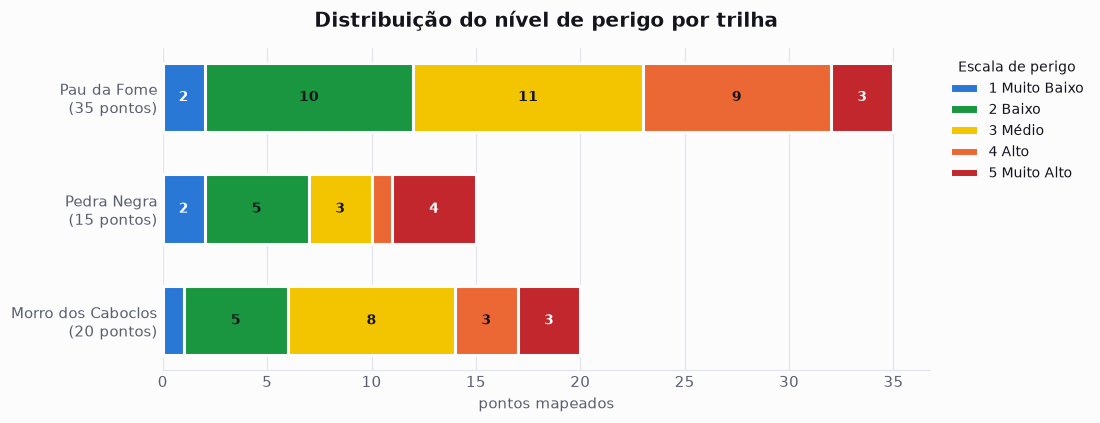

In [8]:
# =====================================================================
# CÉLULA 6 — Distribuição do perigo por trilha
# =====================================================================
ORDEM_TRILHAS = ["Pau da Fome", "Pedra Negra", "Morro dos Caboclos"]
tabela = pd.crosstab(pontos.trilha, pontos.perigo).reindex(ORDEM_TRILHAS)

# o total entra no rótulo do eixo: sem isso, a trilha maior parece pior
# só por ser maior
rotulos = [f"{t}\n({tabela.loc[t].sum()} pontos)" for t in tabela.index]

fig, ax = plt.subplots(figsize=(9, 3.8))
esquerda = pd.Series(0, index=tabela.index)

for cor, tinta_rotulo, nivel in zip(ESCALA_PERIGO, ROTULO_PERIGO_TINTA,
                                    tabela.columns):
    largura = tabela[nivel]
    ax.barh(rotulos, largura, left=esquerda, height=0.62, color=cor,
            edgecolor=SUPERFICIE, linewidth=2, zorder=3, label=nivel)
    for y, (x, v) in enumerate(zip(esquerda, largura)):
        if v >= 2:                       # rotula só onde o texto cabe
            ax.text(x + v/2, y, str(v), ha="center", va="center",
                    color=tinta_rotulo,
                    fontsize=9, fontweight="bold", zorder=4)
    esquerda += largura

ax.set_title("Distribuição do nível de perigo por trilha")
ax.set_xlabel("pontos mapeados")
ax.invert_yaxis()
limpar(ax)
ax.legend(title="Escala de perigo", bbox_to_anchor=(1.01, 1), loc="upper left",
          frameon=False, title_fontsize=9, fontsize=9)
salvar(fig, "01_perigo_por_trilha.png")


salvo: 02_tipos_de_processo.png


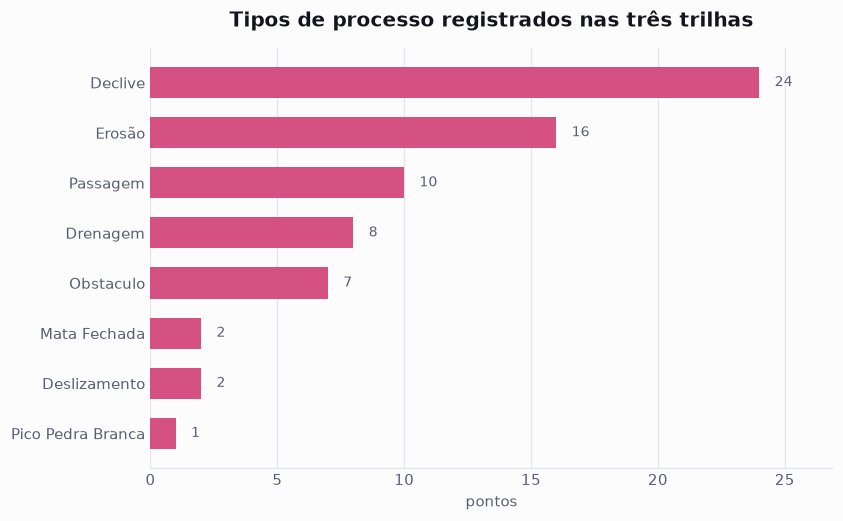

In [9]:
# =====================================================================
# CÉLULA 7 — Frequência dos tipos de processo
# =====================================================================
contagem = pontos.tipo.value_counts().sort_values()

fig, ax = plt.subplots(figsize=(8, 0.42 * len(contagem) + 1.6))
ax.barh(contagem.index, contagem.values, height=0.62,
        color=SERIE_UNICA, zorder=3)
for y, v in enumerate(contagem.values):
    ax.text(v + 0.6, y, str(v), va="center", color=TINTA_FRACA, fontsize=9)

ax.set_title("Tipos de processo registrados nas três trilhas")
ax.set_xlabel("pontos")
ax.set_xlim(0, contagem.max() * 1.12)
limpar(ax)
salvar(fig, "02_tipos_de_processo.png")


salvo: 03_declividade_x_perigo.png


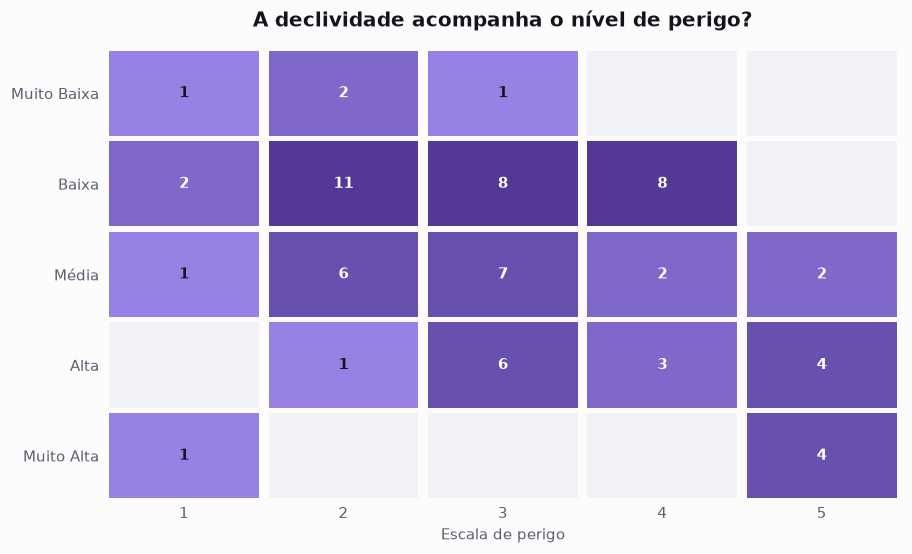

In [10]:
# =====================================================================
# CÉLULA 8 — Mapa de calor reutilizável
# =====================================================================
def mapa_de_calor(tabela, titulo, nome_arquivo,
                  rotulo_x="Escala de perigo", nota=None):
    """Tabela de contingência como grade de células rotuladas.

    Linhas e colunas inteiramente zeradas são descartadas: categorias
    declaradas mas sem ocorrência deixariam faixas vazias no gráfico.
    """
    tabela = tabela.loc[tabela.sum(axis=1) > 0, tabela.sum(axis=0) > 0]
    maximo = tabela.values.max() or 1

    fig, ax = plt.subplots(figsize=(1.15*len(tabela.columns) + 3.6,
                                    0.55*len(tabela.index) + 2.6))
    for i, linha in enumerate(tabela.index):
        for j, coluna in enumerate(tabela.columns):
            v = int(tabela.loc[linha, coluna])
            if v == 0:
                ax.add_patch(plt.Rectangle((j + 0.03, i + 0.03), 0.94, 0.94,
                                           facecolor=VAZIO, edgecolor="none"))
                continue
            # raiz quadrada: sem ela, um valor dominante empurra todo o
            # resto para o tom mais claro e a cor deixa de informar
            intensidade = (v / maximo) ** 0.5
            passo = min(int(intensidade * len(RAMPA_ROXO)), len(RAMPA_ROXO) - 1)
            ax.add_patch(plt.Rectangle((j + 0.03, i + 0.03), 0.94, 0.94,
                                       facecolor=RAMPA_ROXO[passo],
                                       edgecolor="none"))
            ax.text(j + 0.5, i + 0.5, str(v), ha="center", va="center",
                    fontsize=10, fontweight="bold",
                    color="#ffffff" if passo >= 2 else TINTA)

    ax.set_xlim(0, len(tabela.columns))
    ax.set_ylim(len(tabela.index), 0)
    ax.set_xticks([j + 0.5 for j in range(len(tabela.columns))])
    ax.set_xticklabels(tabela.columns)
    ax.set_yticks([i + 0.5 for i in range(len(tabela.index))])
    ax.set_yticklabels(tabela.index)
    ax.set_title(titulo)
    ax.set_xlabel(rotulo_x)
    if nota:
        ax.annotate(nota, xy=(0, -0.16), xycoords="axes fraction",
                    fontsize=9, color=TINTA_FRACA)
    for lado in ax.spines.values():
        lado.set_visible(False)
    ax.tick_params(length=0)
    salvar(fig, nome_arquivo)


mapa_de_calor(
    pd.crosstab(pontos.declividade, pontos.escala_perigo),
    "A declividade acompanha o nível de perigo?",
    "03_declividade_x_perigo.png",
    rotulo_x="Escala de perigo")


salvo:

 04_solo_x_perigo.png
salvo: 05_erosao_x_declividade.png


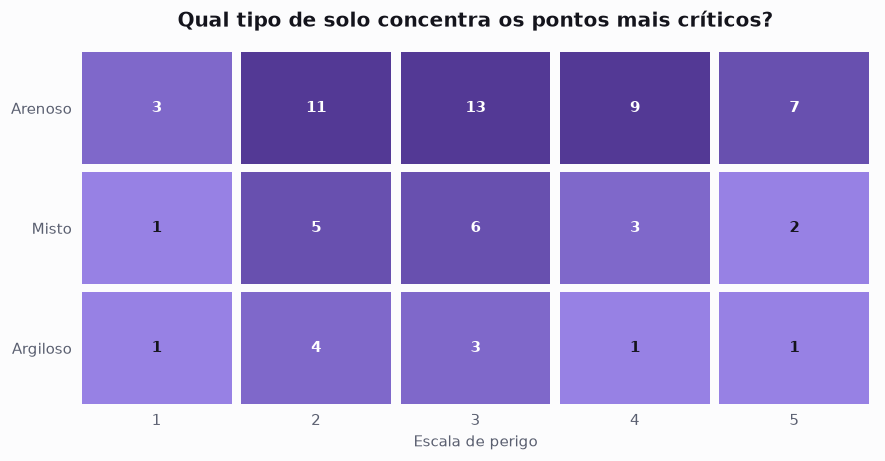

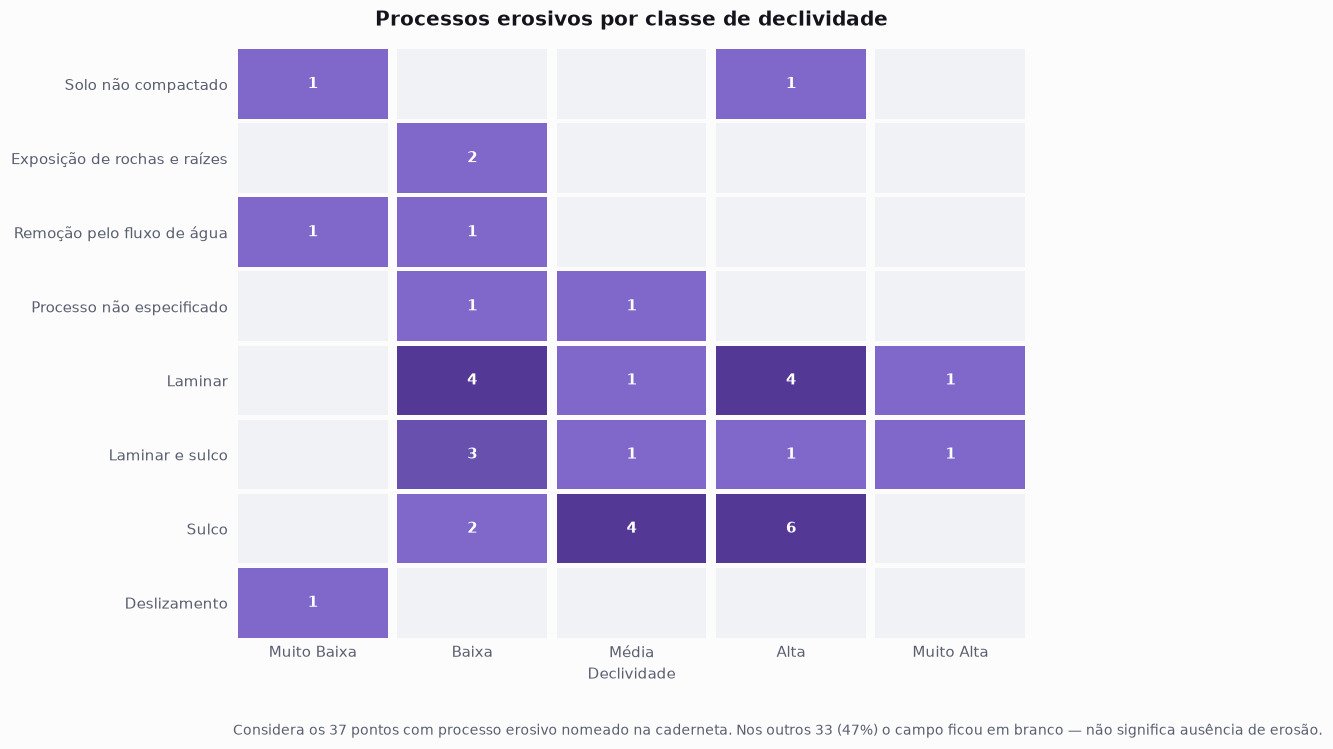

In [11]:
# =====================================================================
# CÉLULA 9 — Solo x perigo e erosão x declividade
# =====================================================================
mapa_de_calor(
    pd.crosstab(pontos.familia_solo, pontos.escala_perigo),
    "Qual tipo de solo concentra os pontos mais críticos?",
    "04_solo_x_perigo.png")

# A classe SEM_REGISTRO reúne 33 dos 70 pontos. Mantida na grade, ela
# domina a escala de cor e some com o contraste entre os processos, que
# é o que a pergunta investiga. Sai do gráfico e entra como nota — mas
# a nota diz que falta o REGISTRO, não que falta a erosão: a maioria
# desses pontos descreve o processo na coluna `obstaculos_riscos`.
com_erosao = pontos[pontos.classe_erosao != SEM_REGISTRO]
sem_registro = len(pontos) - len(com_erosao)

mapa_de_calor(
    pd.crosstab(com_erosao.classe_erosao, com_erosao.declividade),
    "Processos erosivos por classe de declividade",
    "05_erosao_x_declividade.png",
    rotulo_x="Declividade",
    nota=f"Considera os {len(com_erosao)} pontos com processo erosivo "
         f"nomeado na caderneta. Nos outros {sem_registro} "
         f"({100*sem_registro/len(pontos):.0f}%) o campo ficou em branco — "
         f"não significa ausência de erosão.")


salvo: 06_riscos_x_perigo.png
salvo: 07_origem_do_perigo.png
=== O que sustenta a nota de perigo ===
                                  pontos  perigo_medio  criticos  pct_criticos
origem_perigo                                                                 
Sem evidência registrada              21          2.05         1           4.8
Só declividade alta                    6          2.67         1          16.7
Evidências de instabilidade           30          3.23        11          36.7
Declividade alta + instabilidade      13          4.38        10          76.9 

=== Tipo de evidência registrada ===
                                               pontos  perigo_medio  criticos  pct_criticos
tipo_evidencia                                                                             
Sem evidência registrada                           27          2.19         2           7.4
Só instabilidade do terreno                        32          3.69        18          56.2
Instabilidade do t

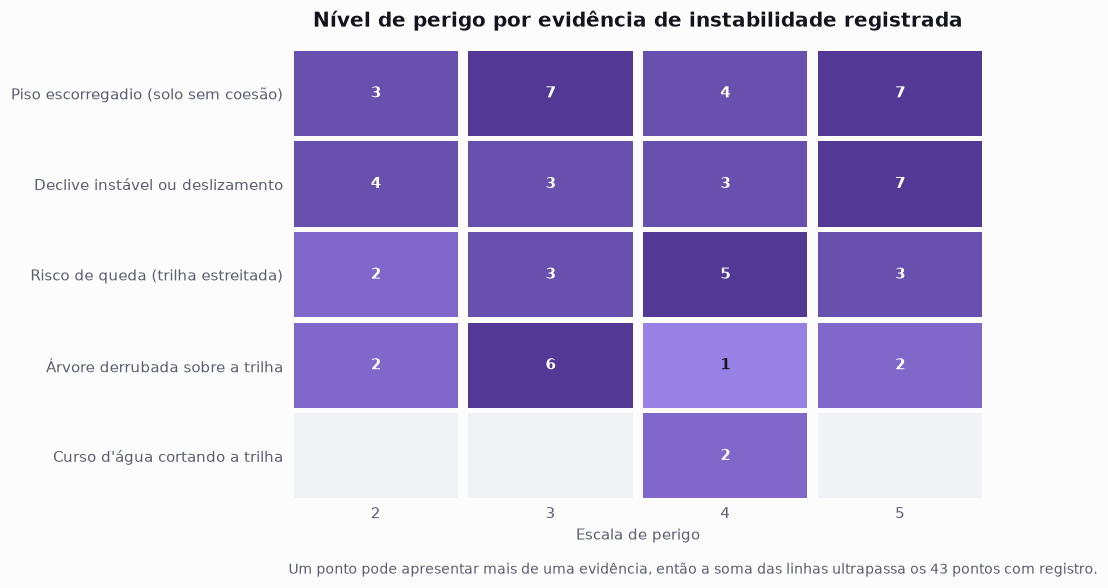

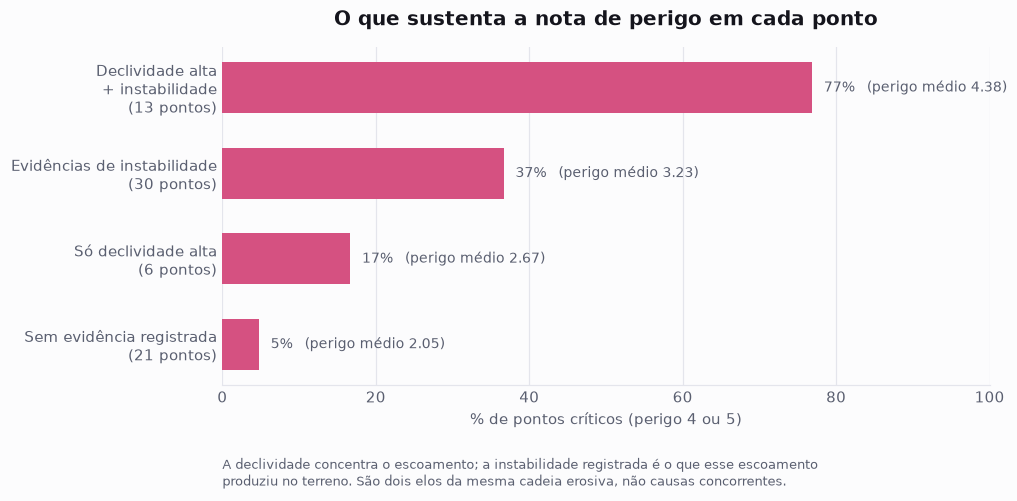

In [12]:
# =====================================================================
# CÉLULA 9B — Evidências de instabilidade x perigo
# =====================================================================
# A cadeia causal deste trabalho é uma só, e todas as categorias abaixo
# estão dentro dela:
#
#   granito e gnaisse fraturados -> intemperismo tropical -> manto de
#   alteração pouco coeso -> declividade + escoamento concentrado ->
#   erosão laminar, sulco e movimento de massa -> raízes expostas,
#   blocos soltos, piso escorregadio, trilha estreitando à beira do
#   declive, árvore derrubada
#
# O que a caderneta anotou na coluna `obstaculos_riscos` é o ÚLTIMO elo
# dessa cadeia: são manifestações do processo erosivo no piso da trilha,
# não uma causa paralela a ele. Por isso esta célula não chama mais essas
# ocorrências de "obstáculos" — o termo sugeria um perigo de origem
# alheia à geologia, que é justamente o contrário do que o trabalho
# defende. Fundamento nas Conclusões do TCC: "Os troncos caídos no meio
# das trilhas estão relacionados com a instabilidade dos solos presentes
# na região, assim como a presença de raízes expostas e blocos soltos
# indicam processos erosivos como a erosão laminar e em sulco."
#
# Os números não mudam em relação à versão anterior — só os rótulos e a
# leitura que eles autorizam.

# --- 1. Marcadores de evidência a partir do texto --------------------
# Um ponto pode apresentar várias evidências ao mesmo tempo ("solo
# escorregadio, risco de queda"), então cada uma é uma coluna
# verdadeiro/falso independente — não uma categoria única.
EVIDENCIAS = {
    "risco_queda":          r"risco de queda|alto risco de queda",
    "risco_escorregamento": r"ri+sco de escorregamento|escorregadio",
    "tronco_galho":         r"tronco|galho|cip[óo]",
    "area_declive":         r"declive|declividade|deslizamento",
    "curso_dagua":          r"\brio\b",
}
NOME_EVIDENCIA = {
    "risco_escorregamento": "Piso escorregadio (solo sem coesão)",
    "area_declive":         "Declive instável ou deslizamento",
    "risco_queda":          "Risco de queda (trilha estreitada)",
    "tronco_galho":         "Árvore derrubada sobre a trilha",
    "curso_dagua":          "Curso d'água cortando a trilha",
}
for nome, padrao in EVIDENCIAS.items():
    pontos[nome] = pontos["obstaculos_riscos"].str.contains(
        padrao, case=False, regex=True)

pontos["n_riscos"] = pontos[list(EVIDENCIAS)].sum(axis=1)

# Duas famílias de evidência, separadas pela posição na cadeia: a
# instabilidade lida no próprio terreno, e a árvore derrubada, que é
# efeito dela — o solo que perdeu coesão deixa de sustentar a raiz.
pontos["instab_terreno"] = pontos[["risco_queda", "risco_escorregamento",
                                   "area_declive", "curso_dagua"]].any(axis=1)
pontos["queda_arvore"] = pontos["tronco_galho"]

# --- 2. Gráfico 6: cada evidência x escala de perigo -----------------
matriz = pd.DataFrame({
    NOME_EVIDENCIA[n]: pontos.loc[pontos[n], "escala_perigo"].value_counts()
    for n in EVIDENCIAS
}).T.reindex(columns=[1, 2, 3, 4, 5], fill_value=0).fillna(0).astype(int)
matriz = matriz.loc[matriz.sum(axis=1).sort_values(ascending=False).index]

mapa_de_calor(
    matriz,
    "Nível de perigo por evidência de instabilidade registrada",
    "06_riscos_x_perigo.png",
    rotulo_x="Escala de perigo",
    nota="Um ponto pode apresentar mais de uma evidência, então a soma das "
         "linhas ultrapassa os 43 pontos com registro.")

# --- 3. Gráfico 7: o que sustenta a nota de perigo do ponto ----------
# Declividade alta e evidência de instabilidade não são causas rivais: a
# declividade é o condicionante que acelera o escoamento, a evidência é o
# resultado visível desse escoamento sobre o manto de alteração. O
# cruzamento serve para mostrar que é a soma dos dois que concentra os
# pontos críticos, não a escolha entre um e outro.
pontos["decliv_alta"] = pontos["declividade"].isin(["Alta", "Muito Alta"])
pontos["tem_evidencia"] = pontos["obstaculos_riscos"] != ""

def origem_do_perigo(linha):
    if linha.decliv_alta and linha.tem_evidencia:
        return "Declividade alta + instabilidade"
    if linha.decliv_alta:
        return "Só declividade alta"
    if linha.tem_evidencia:
        return "Evidências de instabilidade"
    return "Sem evidência registrada"

pontos["origem_perigo"] = pontos.apply(origem_do_perigo, axis=1)

origem = pontos.groupby("origem_perigo").agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
)
origem["pct_criticos"] = (100 * origem.criticos / origem.pontos_).round(1)
origem["perigo_medio"] = origem.perigo_medio.round(2)
origem = origem.sort_values("pct_criticos")

fig, ax = plt.subplots(figsize=(9, 4.0))
# a quebra de linha é decisão de rótulo, não de dado: entra só aqui
QUEBRA_ROTULO = {
    "Declividade alta + instabilidade": "Declividade alta\n+ instabilidade"}
rotulos = [f"{QUEBRA_ROTULO.get(i, i)}\n({int(r.pontos_)} pontos)"
           for i, r in origem.iterrows()]
ax.barh(rotulos, origem.pct_criticos, height=0.6, color=SERIE_UNICA, zorder=3)
for y, (pct, media) in enumerate(zip(origem.pct_criticos, origem.perigo_medio)):
    ax.text(pct + 1.5, y, f"{pct:.0f}%   (perigo médio {media})",
            va="center", color=TINTA_FRACA, fontsize=9)

ax.set_title("O que sustenta a nota de perigo em cada ponto")
ax.set_xlabel("% de pontos críticos (perigo 4 ou 5)")
ax.set_xlim(0, 100)
ax.annotate("A declividade concentra o escoamento; a instabilidade registrada "
            "é o que esse escoamento\nproduziu no terreno. São dois elos da "
            "mesma cadeia erosiva, não causas concorrentes.",
            xy=(0, -0.21), xycoords="axes fraction",
            fontsize=8.5, color=TINTA_FRACA, va="top")
limpar(ax)
salvar(fig, "07_origem_do_perigo.png")

# --- 4. A árvore derrubada como efeito, e não como causa -------------
# Dos 43 pontos com evidência registrada, apenas 6 trazem exclusivamente
# a árvore caída; os outros 5 que a citam vêm no mesmo texto acompanhados
# de declive instável ou piso escorregadio. Ou seja, ela quase nunca
# aparece sozinha — acompanha o solo que deixou de segurá-la, exatamente
# como o TCC descreve ("aparentam ter sido derrubados devido à
# instabilidade do solo").
def tipo_de_evidencia(linha):
    if not linha.tem_evidencia:
        return "Sem evidência registrada"
    if linha.queda_arvore and linha.instab_terreno:
        return "Instabilidade do terreno + árvore derrubada"
    if linha.queda_arvore:
        return "Só árvore derrubada (efeito da instabilidade)"
    return "Só instabilidade do terreno"

ORDEM_TIPO_EVIDENCIA = [
    "Sem evidência registrada",
    "Só instabilidade do terreno",
    "Instabilidade do terreno + árvore derrubada",
    "Só árvore derrubada (efeito da instabilidade)",
]
pontos["tipo_evidencia"] = pd.Categorical(
    pontos.apply(tipo_de_evidencia, axis=1),
    categories=ORDEM_TIPO_EVIDENCIA, ordered=True)

evidencia = pontos.groupby("tipo_evidencia", observed=True).agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
)
evidencia["pct_criticos"] = (100 * evidencia.criticos / evidencia.pontos_).round(1)
evidencia["perigo_medio"] = evidencia.perigo_medio.round(2)

# --- 5. Tabelas ------------------------------------------------------
origem.rename(columns={"pontos_": "pontos"}).to_csv(
    SAIDA_CSV / "origem_do_perigo.csv", index_label="origem",
    encoding="utf-8-sig")
matriz.to_csv(SAIDA_CSV / "riscos_x_perigo.csv", index_label="risco",
              encoding="utf-8-sig")
evidencia.rename(columns={"pontos_": "pontos"}).to_csv(
    SAIDA_CSV / "evidencia_por_tipo.csv", index_label="tipo_evidencia",
    encoding="utf-8-sig")

print("=== O que sustenta a nota de perigo ===")
print(origem.rename(columns={"pontos_": "pontos"}).to_string(), "\n")
print("=== Tipo de evidência registrada ===")
print(evidencia.rename(columns={"pontos_": "pontos"}).to_string(), "\n")
print("=== Perigo por quantidade de evidências acumuladas no mesmo ponto ===")
print(pontos.groupby("n_riscos").agg(
    pontos=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum")).round(2).to_string())


salvo: 08_erosao_x_perigo.png
=== Perigo por severidade do processo erosivo ===
                              pontos  perigo_medio  criticos  pct_criticos
grupo_erosao                                                              
Sem sinal erosivo registrado      33          3.00        13          39.4
Erosão laminar                    10          3.20         4          40.0
Laminar evoluindo p/ sulco         6          2.83         1          16.7
Erosão em sulco                   12          3.00         2          16.7
Outros processos                   9          3.22         3          33.3 

=== Com sinal registrado x sem sinal registrado ===
                              pontos  perigo_medio  criticos  pct_criticos
Sem sinal erosivo registrado      33          3.00        13          39.4
Com sinal erosivo registrado      37          3.08        10          27.0 

=== Dos 33 pontos sem sinal erosivo registrado, 22 descrevem instabilidade na outra coluna ===
  T1P005  Rio
  T1P

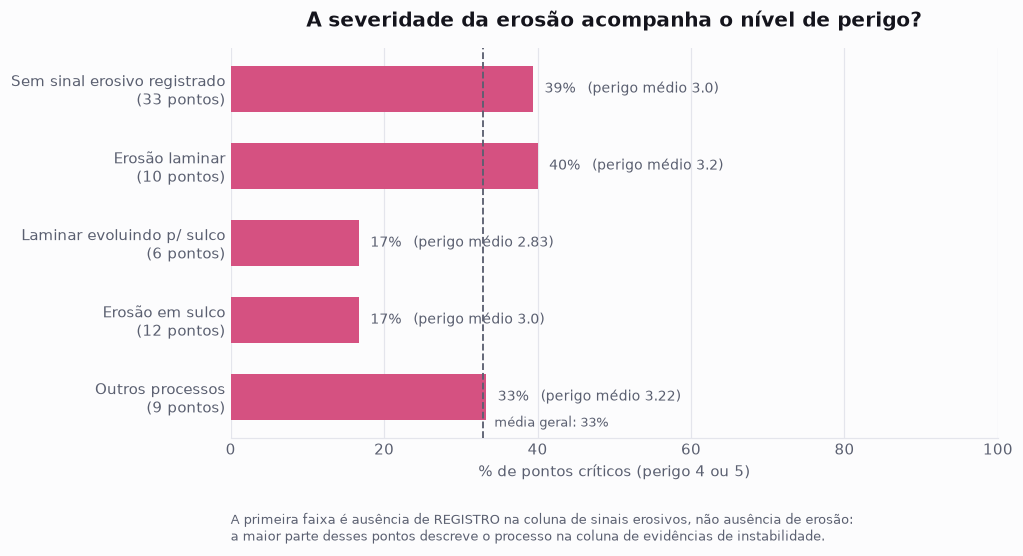

In [13]:
# =====================================================================
# CÉLULA 9C — Sinais de erosão x perigo
# =====================================================================
# O estágio erosivo consta como um dos critérios da escala de perigo.
# Esta célula verifica se ele de fato discrimina.
#
# Atenção ao primeiro grupo: "Sem sinal erosivo registrado" NÃO quer
# dizer ponto sem erosão. Quer dizer que a coluna `sinais_erosao` da
# caderneta ficou em branco naquele ponto — e, na maioria das vezes, o
# processo foi descrito na outra coluna, `obstaculos_riscos`. O bloco 4
# desta célula quantifica isso, para que a barra baixa desse grupo não
# seja lida como "aqui o perigo não vem da erosão".

# --- 1. Agrupamento por severidade -----------------------------------
# As nove classes da Célula 3 são detalhadas demais para cruzar: cinco
# delas têm 1 ou 2 pontos. Agrupadas por severidade do processo, com
# os casos raros reunidos em "Outros processos".
SEVERIDADE = {
    SEM_REGISTRO:                   SEM_REGISTRO,
    "Laminar":                      "Erosão laminar",
    "Laminar e sulco":              "Laminar evoluindo p/ sulco",
    "Sulco":                        "Erosão em sulco",
    "Solo não compactado":          "Outros processos",
    "Exposição de rochas e raízes": "Outros processos",
    "Remoção pelo fluxo de água":   "Outros processos",
    "Processo não especificado":    "Outros processos",
    "Deslizamento":                 "Outros processos",
}
ORDEM_SEVERIDADE = [SEM_REGISTRO, "Erosão laminar",
                    "Laminar evoluindo p/ sulco", "Erosão em sulco",
                    "Outros processos"]

pontos["grupo_erosao"] = pd.Categorical(
    pontos["classe_erosao"].map(SEVERIDADE),
    categories=ORDEM_SEVERIDADE, ordered=True)

# --- 2. Gráfico 8: severidade da erosão x perigo ---------------------
erosao = pontos.groupby("grupo_erosao", observed=True).agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
)
erosao["pct_criticos"] = (100 * erosao.criticos / erosao.pontos_).round(1)
erosao["perigo_medio"] = erosao.perigo_medio.round(2)

media_geral = 100 * pontos.critico.sum() / len(pontos)

fig, ax = plt.subplots(figsize=(9, 4.6))
rotulos = [f"{i}\n({int(r.pontos_)} pontos)" for i, r in erosao.iterrows()]
ax.barh(rotulos, erosao.pct_criticos, height=0.6, color=SERIE_UNICA, zorder=3)
for y, (pct, media) in enumerate(zip(erosao.pct_criticos, erosao.perigo_medio)):
    ax.text(pct + 1.5, y, f"{pct:.0f}%   (perigo médio {media})",
            va="center", color=TINTA_FRACA, fontsize=9)

# linha de referência: se a erosão não pesasse, todas as barras
# ficariam em torno da média geral
ax.axvline(media_geral, color=TINTA_FRACA, linestyle="--", linewidth=1.2,
           zorder=4)
ax.annotate(f"média geral: {media_geral:.0f}%",
            xy=(media_geral + 1.5, 0.02), xycoords=("data", "axes fraction"),
            fontsize=8.5, color=TINTA_FRACA, va="bottom")

ax.set_title("A severidade da erosão acompanha o nível de perigo?")
ax.set_xlabel("% de pontos críticos (perigo 4 ou 5)")
ax.set_xlim(0, 100)
ax.invert_yaxis()
ax.annotate("A primeira faixa é ausência de REGISTRO na coluna de sinais "
            "erosivos, não ausência de erosão:\na maior parte desses pontos "
            "descreve o processo na coluna de evidências de instabilidade.",
            xy=(0, -0.19), xycoords="axes fraction",
            fontsize=8.5, color=TINTA_FRACA, va="top")
limpar(ax)
salvar(fig, "08_erosao_x_perigo.png")

# --- 3. Comparação agregada ------------------------------------------
pontos["tem_erosao"] = pontos["classe_erosao"] != SEM_REGISTRO
agregado = pontos.groupby("tem_erosao").agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
).round(2)
agregado.index = [SEM_REGISTRO, "Com sinal erosivo registrado"]
agregado["pct_criticos"] = (100 * agregado.criticos / agregado.pontos_).round(1)

erosao.rename(columns={"pontos_": "pontos"}).to_csv(
    SAIDA_CSV / "erosao_severidade_x_perigo.csv", index_label="grupo_erosao",
    encoding="utf-8-sig")

print("=== Perigo por severidade do processo erosivo ===")
print(erosao.rename(columns={"pontos_": "pontos"}).to_string(), "\n")
print("=== Com sinal registrado x sem sinal registrado ===")
print(agregado.rename(columns={"pontos_": "pontos"}).to_string(), "\n")

# --- 4. Auditoria do grupo sem registro ------------------------------
# Mostra ponto a ponto que "sem registro" não é "sem erosão": o texto
# abaixo veio da coluna `obstaculos_riscos` dos mesmos pontos.
sem_registro = pontos[~pontos.tem_erosao]
com_evidencia = sem_registro[sem_registro.obstaculos_riscos != ""]
print(f"=== Dos {len(sem_registro)} pontos sem sinal erosivo registrado, "
      f"{len(com_evidencia)} descrevem instabilidade na outra coluna ===")
for _, p in com_evidencia.iterrows():
    print(f"  {p.id_ponto}  {p.obstaculos_riscos[:78]}")

# --- 5. Indicador combinado: as duas colunas lidas como uma só -------
# A caderneta partiu a evidência do mesmo processo em duas colunas, e
# nenhuma delas isolada mede "há processo erosivo atuante neste ponto".
# Unindo as duas, o quadro fica coerente com o que o TCC afirma: onde
# há qualquer registro do processo, está o perigo; onde não há nenhum,
# não há ponto crítico.
pontos["tem_evidencia_processo"] = (
    (pontos["sinais_erosao"] != "") | (pontos["obstaculos_riscos"] != ""))

combinado = pontos.groupby("tem_evidencia_processo").agg(
    pontos_=("id_ponto", "count"),
    perigo_medio=("escala_perigo", "mean"),
    criticos=("critico", "sum"),
).round(2)
combinado.index = ["Nenhuma das duas colunas preenchida",
                   "Evidência do processo em alguma das colunas"]
combinado["pct_criticos"] = (100 * combinado.criticos / combinado.pontos_).round(1)

combinado.rename(columns={"pontos_": "pontos"}).to_csv(
    SAIDA_CSV / "evidencia_combinada.csv", index_label="evidencia",
    encoding="utf-8-sig")

print("\n=== Indicador combinado (sinais_erosao OU obstaculos_riscos) ===")
print(combinado.rename(columns={"pontos_": "pontos"}).to_string())


In [14]:
# =====================================================================
# CÉLULA 10 — Exportação
# =====================================================================

# Confere se as células anteriores rodaram: sem as colunas derivadas,
# a exportação sairia incompleta e sem avisar.
DERIVADAS = {
    "Célula 3":  ["trilha", "perigo", "critico", "familia_solo", "classe_erosao"],
    "Célula 9b": ["n_riscos", "origem_perigo", "tem_evidencia",
                  "instab_terreno", "queda_arvore", "tipo_evidencia",
                  "risco_queda", "risco_escorregamento", "tronco_galho",
                  "area_declive", "curso_dagua"],
    "Célula 9c": ["grupo_erosao", "tem_erosao"],
}
for celula, colunas in DERIVADAS.items():
    faltando = [c for c in colunas if c not in pontos.columns]
    if faltando:
        print(f"ATENÇÃO — rode a {celula} antes desta. Faltam: {faltando}\n")

tabelas = {
    "perigo_por_trilha":       pd.crosstab(pontos.trilha, pontos.perigo),
    "tipos_por_trilha":        pd.crosstab(pontos.tipo, pontos.trilha),
    "declividade_x_perigo":    pd.crosstab(pontos.declividade, pontos.escala_perigo),
    "solo_x_perigo":           pd.crosstab(pontos.familia_solo, pontos.escala_perigo),
    "solo_detalhado_x_perigo": pd.crosstab(pontos.solo, pontos.escala_perigo),
    "erosao_x_declividade":    pd.crosstab(pontos.classe_erosao, pontos.declividade),
    "erosao_x_perigo":         pd.crosstab(pontos.classe_erosao, pontos.escala_perigo),
    "origem_x_trilha":         pd.crosstab(pontos.origem_perigo, pontos.trilha),
    "erosao_x_origem":         pd.crosstab(pontos.grupo_erosao, pontos.origem_perigo),
    "erosao_x_evidencia":      pd.crosstab(pontos.grupo_erosao, pontos.tipo_evidencia),
}
for nome, tabela in tabelas.items():
    tabela.to_csv(SAIDA_CSV / f"{nome}.csv", encoding="utf-8-sig")

# Base completa para o Power BI, com as colunas derivadas nas Células 3, 9b e 9c.
# `condicoes_trilha` fica de fora: 70 descrições únicas de ~112 caracteres
# não alimentam nenhum visual.
base = pontos.drop(columns=["condicoes_trilha"])

# Colunas de ordenação para o Power BI. Ele ordena texto alfabeticamente
# ("Alta, Baixa, Média..."), então cada categórica ordenada leva junto o
# número da sua posição. Elas precisam vir do arquivo, e não de uma coluna
# calculada em DAX: o Power BI recusa ordenar uma coluna por outra que
# derive dela — acusa dependência circular.
ORDEM_ORIGEM = ["Sem evidência registrada", "Só declividade alta",
                "Evidências de instabilidade", "Declividade alta + instabilidade"]
ORDENACOES = [("ordem_declividade", "declividade",     ORDEM_DECLIVIDADE),
              ("ordem_erosao",      "grupo_erosao",    ORDEM_SEVERIDADE),
              ("ordem_origem",      "origem_perigo",   ORDEM_ORIGEM),
              ("ordem_evidencia",   "tipo_evidencia",  ORDEM_TIPO_EVIDENCIA)]
for nome, coluna, ordem in ORDENACOES:
    posicao = {v: i + 1 for i, v in enumerate(ordem)}
    base[nome] = base[coluna].astype(str).map(posicao).fillna(99).astype(int)
    fora = sorted(set(base.loc[base[nome] == 99, coluna].astype(str)))
    if fora:
        print(f"ATENÇÃO — {coluna}: valores fora da ordem definida: {fora}\n")

base.to_csv(SAIDA_CSV / "pontos_completo.csv", index=False, encoding="utf-8-sig")
fotos.to_csv(SAIDA_CSV / "fotos_completo.csv", index=False, encoding="utf-8-sig")

print(f"Imagens geradas ({len(list(SAIDA_IMG.glob('*.png')))}):")
for a in sorted(SAIDA_IMG.glob("*.png")):
    print(f"   {a.name:<34} {a.stat().st_size//1024:>4} KB")

print(f"\nTabelas geradas ({len(list(SAIDA_CSV.glob('*.csv')))}):")
for a in sorted(SAIDA_CSV.glob("*.csv")):
    print(f"   {a.name}")

print(f"\npontos_completo.csv: {len(base)} linhas x {len(base.columns)} colunas")
print("colunas:", ", ".join(base.columns))


Imagens geradas (8):
   01_perigo_por_trilha.png             73 KB
   02_tipos_de_processo.png             52 KB
   03_declividade_x_perigo.png          43 KB
   04_solo_x_perigo.png                 36 KB
   05_erosao_x_declividade.png          97 KB
   06_riscos_x_perigo.png               76 KB
   07_origem_do_perigo.png             106 KB
   08_erosao_x_perigo.png              126 KB

Tabelas geradas (18):
   declividade_x_perigo.csv
   erosao_severidade_x_perigo.csv
   erosao_x_declividade.csv
   erosao_x_evidencia.csv
   erosao_x_origem.csv
   erosao_x_perigo.csv
   evidencia_combinada.csv
   evidencia_por_tipo.csv
   fotos_completo.csv
   origem_do_perigo.csv
   origem_x_trilha.csv
   perigo_por_trilha.csv
   pontos_completo.csv
   riscos_x_perigo.csv
   sintese_por_trilha.csv
   solo_detalhado_x_perigo.csv
   solo_x_perigo.csv
   tipos_por_trilha.csv

pontos_completo.csv: 70 linhas x 35 colunas
colunas: id_ponto, id_trilha, tipo, declividade, solo, sinais_erosao, obstaculos_risco